# Options-implied tail risk

Risk-neutral densities from the WTI futures option chains (`data/raw/Oil_Futures_Options.xlsx`). See `reports/OPTIONS_TAIL_RISK.md` for the generated write-up and caveats (risk-neutral ≠ physical probabilities).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from oil_models import options_rnd as orx

In [2]:
chains = orx.parse_chains()
[(c.label, c.contract, c.days, c.future) for c in chains]

[('Jul-26', 'CLN6', 6, 88.83),
 ('Aug-26', 'CLQ6', 36, 87.16),
 ('Sep-26', 'CLU6', 68, 85.22),
 ('Oct-26', 'CLV6', 99, 83.43),
 ('Nov-26', 'CLX6', 127, 81.83),
 ('Dec-26', 'CLZ6', 160, 80.41)]

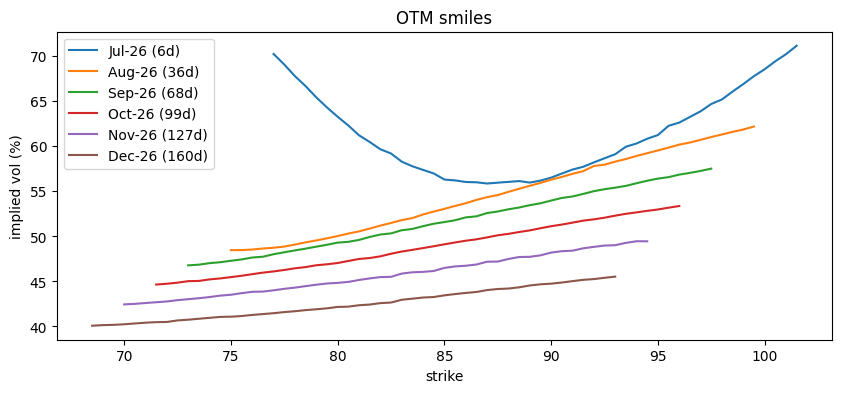

In [3]:
fig, ax = plt.subplots(figsize=(10,4))
for c in chains:
    sm = orx.otm_smile(c)
    ax.plot(sm.strike, sm.iv, label=f'{c.label} ({c.days}d)')
ax.set(xlabel='strike', ylabel='implied vol (%)', title='OTM smiles'); ax.legend();

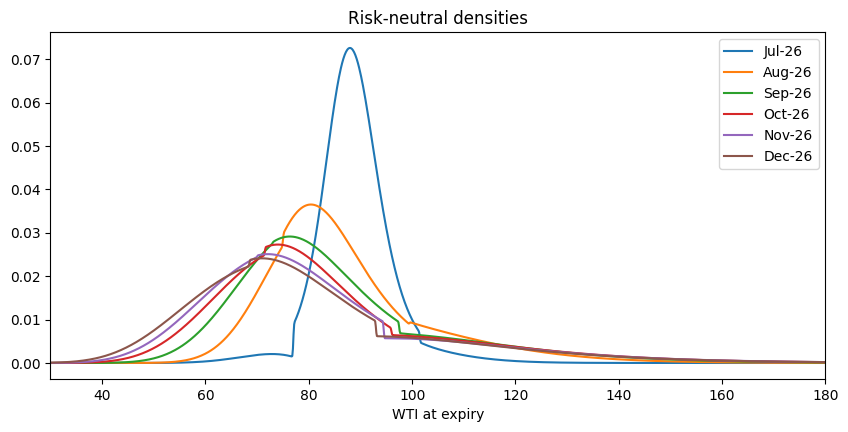

In [4]:
rnds = [orx.fit_rnd(c) for c in chains]
fig, ax = plt.subplots(figsize=(10,4.5))
for r in rnds:
    ax.plot(r.grid, r.density, label=r.chain.label)
ax.set(xlim=(30,180), xlabel='WTI at expiry', title='Risk-neutral densities'); ax.legend();

In [5]:
orx.tail_table(rnds)

,days,future,rn_mean,P(>$100),P(>$120),P(>$150),q05,q50,q95,q99
expiry,,,,,,,,,,
Jul-26,6,88.83,88.830000,0.052050,0.002530,0.000004,79.076187,88.439826,100.094746,111.489503
Aug-26,36,87.16,87.159985,0.171199,0.048241,0.004059,67.406412,83.778462,119.447778,139.674675
Sep-26,68,85.22,85.217272,0.178816,0.073383,0.013072,60.713606,80.639621,127.188388,154.266306
Oct-26,99,83.43,83.417414,0.181142,0.079936,0.017309,56.099409,78.334504,129.690170,159.901618
Nov-26,127,81.83,81.804804,0.173165,0.079470,0.018536,53.302112,76.689328,129.991431,161.857823
Dec-26,160,80.41,80.377563,0.169536,0.075936,0.017805,50.644403,75.426515,128.989010,161.139465
